In [98]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report

In [99]:
def insect_load():
    train = pd.read_csv('/Users/nathanjones/Downloads/NUWE/CodingChallenges/Insect_Classification/repo_insect_classification/nuwe-data-ml1/data/train.csv')
    test = pd.read_csv('/Users/nathanjones/Downloads/NUWE/CodingChallenges/Insect_Classification/repo_insect_classification/nuwe-data-ml1/data/test.csv')
    print('load complete')
    return train, test

In [100]:
train, test = insect_load()

load complete


In [101]:
def insect_prepocessing(df):
    df.fillna(df.median(), inplace=True)
    df["hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)
    print('prepocessing complete')
    return df 


In [102]:
train_df = insect_prepocessing(train)
test_df = insect_prepocessing(test)

prepocessing complete
prepocessing complete


In [103]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4900 entries, 0 to 4899
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         4900 non-null   int64  
 1   Hour               4900 non-null   int64  
 2   Minutes            4900 non-null   int64  
 3   Sensor_alpha       4900 non-null   float64
 4   Sensor_beta        4900 non-null   float64
 5   Sensor_gamma       4900 non-null   float64
 6   Sensor_alpha_plus  4900 non-null   float64
 7   Sensor_beta_plus   4900 non-null   float64
 8   Sensor_gamma_plus  4900 non-null   float64
 9   Insect             4900 non-null   int64  
 10  hour_sin           4900 non-null   float64
 11  hour_cos           4900 non-null   float64
dtypes: float64(8), int64(4)
memory usage: 459.5 KB


In [104]:
train_df.head(10)

,Unnamed: 0,Hour,Minutes,Sensor_alpha,Sensor_beta,Sensor_gamma,Sensor_alpha_plus,Sensor_beta_plus,Sensor_gamma_plus,Insect,hour_sin,hour_cos
0,978,20,32,9.357810,-13.449364,-69.354962,-43.623548,-13.350178,90.339612,0,-0.866025,5.000000e-01
1,3050,21,51,95.506060,-43.804706,-62.256674,-26.534959,-71.464030,123.662640,0,-0.707107,7.071068e-01
2,4961,18,57,65.979380,-201.737079,-153.599256,88.683294,105.043351,-133.978404,0,-1.000000,-1.836970e-16
3,2548,21,27,-98.791430,74.576430,58.463369,-82.034567,94.201092,-34.944169,1,-0.707107,7.071068e-01
4,848,18,40,59.908086,-264.228327,-238.913552,35.186946,-282.192584,-76.129129,0,-1.000000,-1.836970e-16
5,3484,22,17,82.743649,89.880433,36.025142,82.939134,-122.948928,-39.149256,0,-0.500000,8.660254e-01
6,3282,23,20,-115.057914,20.190329,-52.912861,-116.743631,29.399207,-48.032972,2,-0.258819,9.659258e-01
7,3861,19,44,-83.842830,136.251473,14.838888,-120.339316,-100.030933,202.508957,0,-0.965926,2.588190e-01
8,2131,23,48,80.638730,94.915763,-156.503681,17.171525,68.965492,88.164962,2,-0.258819,9.659258e-01
9,47,19,58,-30.610388,144.810603,50.454143,70.899688,166.876374,-170.684018,0,-0.965926,2.588190e-01


In [105]:
train_df.describe()

,Unnamed: 0,Hour,Minutes,Sensor_alpha,Sensor_beta,Sensor_gamma,Sensor_alpha_plus,Sensor_beta_plus,Sensor_gamma_plus,Insect,hour_sin,hour_cos
count,4900.000000,4900.000000,4900.000000,4900.000000,4900.000000,4900.000000,4900.000000,4900.000000,4900.000000,4900.000000,4900.000000,4900.000000
mean,3531.120408,19.602857,29.364490,-0.562778,-31.431049,-7.079190,9.073422,-0.462028,0.026668,0.594694,-0.675150,0.506653
std,2020.098650,3.508342,17.428834,99.204111,132.502870,115.947373,122.293572,100.430259,100.022316,0.663864,0.360570,0.396892
min,0.000000,1.000000,0.000000,-404.898823,-656.272666,-448.478039,-437.205393,-343.451101,-368.345520,0.000000,-1.000000,-1.000000
25%,1796.750000,19.000000,14.000000,-70.732844,-117.775428,-85.725422,-78.197223,-68.066902,-68.326265,0.000000,-0.866025,0.258819
50%,3549.500000,21.000000,29.000000,-0.170905,-38.146457,-2.744884,1.913897,-0.063244,-0.099972,0.000000,-0.707107,0.707107
75%,5287.500000,21.000000,44.000000,66.305808,55.435097,74.769456,96.092930,67.062175,67.351239,1.000000,-0.707107,0.707107
max,7000.000000,23.000000,59.000000,351.256221,518.395878,378.349287,462.556319,345.279240,347.793230,2.000000,1.000000,0.965926


<Axes: xlabel='Sensor_gamma_plus'>

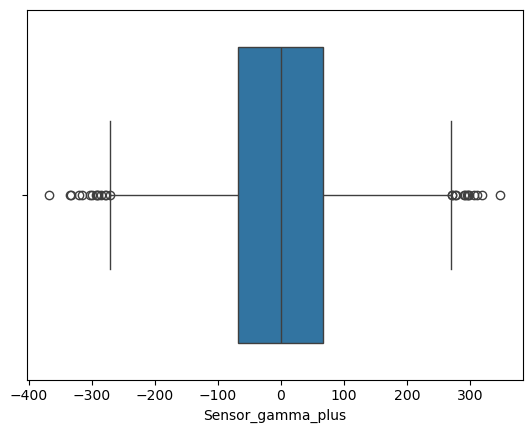

In [106]:
sns.boxplot(data=train_df, x='Sensor_gamma_plus')

<Axes: xlabel='Insect', ylabel='Count'>

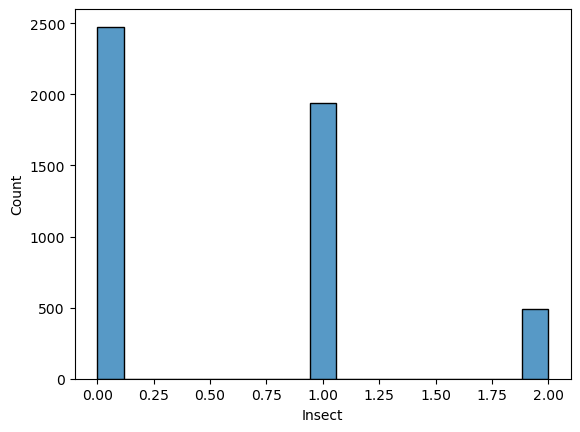

In [107]:
sns.histplot(train_df['Insect'])

In [108]:
train_df['Insect'].value_counts()

Insect
0    2475
1    1936
2     489
Name: count, dtype: int64

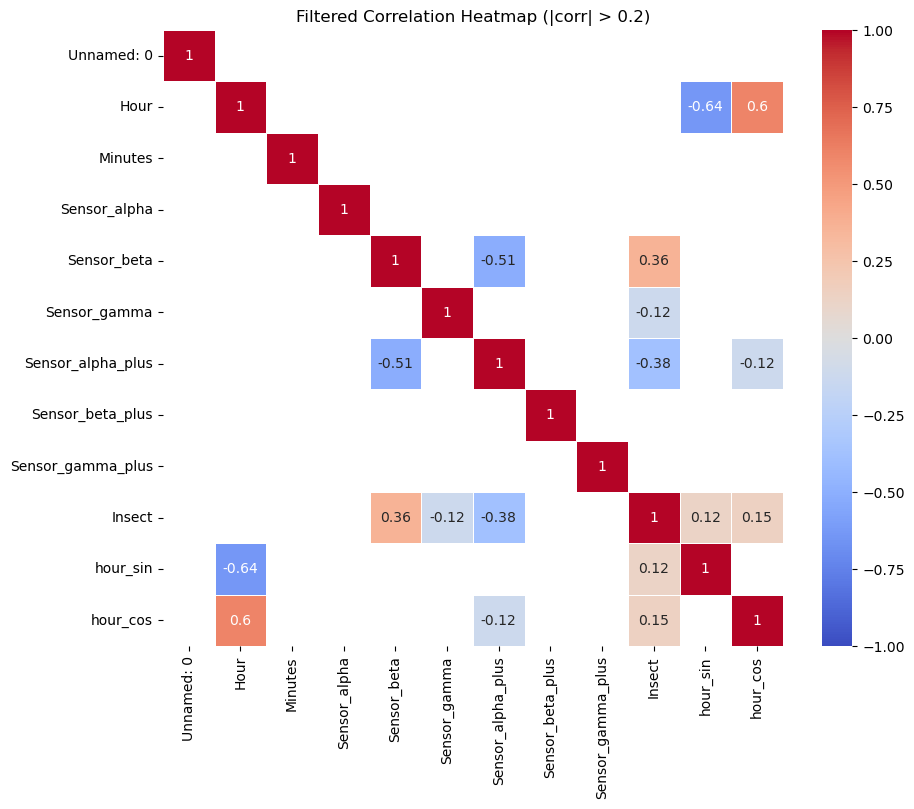

In [109]:


# Compute correlation matrix
corr = train_df.corr()

# Apply threshold: Keep only correlations above |0.2|, set the rest to NaN
corr_filtered = corr.where(abs(corr) > 0.1)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_filtered, annot=True, cmap="coolwarm", linewidths=0.5, vmin=-1, vmax=1)

plt.title("Filtered Correlation Heatmap (|corr| > 0.2)")
plt.show()


In [110]:
features = ['hour_sin', 'hour_cos', 'Sensor_beta', 'Sensor_gamma', 'Sensor_alpha_plus']
X = train_df[features]
y = train_df['Insect']
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.15, random_state=24, stratify=y)

print('train_X', train_X.shape)
print('train_y', train_y.shape)

print('test_X', test_X.shape)
print('test_y', test_y.shape)


train_X (4165, 5)
train_y (4165,)
test_X (735, 5)
test_y (735,)


In [111]:
print("Training Set Class Distribution:")
print(train_y.value_counts(normalize=True))

print("\nTest Set Class Distribution:")
print(test_y.value_counts(normalize=True))


Training Set Class Distribution:
Insect
0    0.505162
1    0.394958
2    0.099880
Name: proportion, dtype: float64

Test Set Class Distribution:
Insect
0    0.504762
1    0.395918
2    0.099320
Name: proportion, dtype: float64


In [118]:
rfc = RandomForestClassifier(n_estimators=100, random_state=24, class_weight='balanced')

rfc.fit(train_X, train_y)

RandomForestClassifier(class_weight='balanced', random_state=24)

In [119]:
cv = StratifiedKFold(shuffle=True, n_splits=5, random_state=24)
f1_scores = cross_val_score(rfc, train_X, train_y, cv=cv, scoring='f1_weighted')
print(f"Cross-validation F1-scores: {f1_scores}")
print(f"Mean F1-score: {np.mean(f1_scores):.4f}")

Cross-validation F1-scores: [0.89145828 0.8683528  0.87188973 0.9120295  0.86859648]
Mean F1-score: 0.8825


In [120]:
y_pred = rfc.predict(test_X)
print(classification_report(test_y, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.92      0.92       371
           1       0.91      0.96      0.93       291
           2       0.87      0.64      0.74        73

    accuracy                           0.91       735
   macro avg       0.90      0.84      0.86       735
weighted avg       0.91      0.91      0.91       735

